In [1]:
import pandas as pd
import re
import os
import paramiko
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations
from pprint import pprint
from itertools import chain
from sqlalchemy import create_engine
ssh = paramiko.SSHClient()
ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy()) 
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt

Load all data

In [2]:
nsx_ds_multiqc = pd.read_csv(r'c:\Users\glj523\OneDrive - University of Copenhagen\data\illumina_analysis\abidmux_qc_AOZCK_full.csv')
all_ns6_multiqc = pd.read_csv(r'c:\Users\glj523\OneDrive - University of Copenhagen\data\illumina_analysis\all_ns6_multiqc.csv')
nsx_ss_multiqc = pd.read_csv(r'c:\Users\glj523\OneDrive - University of Copenhagen\data\illumina_analysis\ill_dmux_multiqc_ss_full.csv')

nsx_ss_multiqc['Protocol'] = 'Single'
nsx_ds_multiqc['Protocol'] = 'Double'

all_nsx_multiqc = pd.concat([nsx_ds_multiqc, nsx_ss_multiqc]).reset_index(drop=True)
all_nsx_multiqc['Platform'] = 'NovaSeqX'

# Remove diffs
diff_lib = set(all_nsx_multiqc.library_id) ^ set(all_ns6_multiqc.library_id) 
all_nsx_multiqc = all_nsx_multiqc[~all_nsx_multiqc['library_id'].isin(diff_lib)]
all_ns6_multiqc = all_ns6_multiqc[~all_ns6_multiqc['library_id'].isin(diff_lib)]
print(f'removed {diff_lib} from dataframes')

all_nsx_multiqc['Lane'] = all_nsx_multiqc['suffix'].apply(lambda x: x.split('_')[0])
all_nsx_multiqc['Read Type'] = all_nsx_multiqc['suffix'].apply(lambda x: x.split('_')[1] if len(x.split('_')) > 1 else None)
diff_cols = set(all_ns6_multiqc.columns) ^ set(all_nsx_multiqc.columns)

all_nsx_multiqc = all_nsx_multiqc.drop(columns=diff_cols, errors='ignore')
all_ns6_multiqc = all_ns6_multiqc.drop(columns=diff_cols, errors='ignore')
print(f'removed {diff_cols} from dataframes')

all_multiqc_data = pd.concat([all_ns6_multiqc, all_nsx_multiqc]).reset_index(drop=True)

data_ns6 = all_ns6_multiqc
data_nsX = all_nsx_multiqc
data_ns6_ss = data_ns6[data_ns6['Protocol'] == 'Single']
data_nsX_ss = data_nsX[data_nsX['Protocol'] == 'Single']
data_ns6_ds = data_ns6[data_ns6['Protocol'] == 'Double']
data_nsX_ds = data_nsX[data_nsX['Protocol'] == 'Double']

removed {'LV7009026461', 'LV7008960913'} from dataframes
removed {'config_output_dir', 'fastq_id', 'qc_type', 'suffix', 'eDNA Concentration', 'Project'} from dataframes


In [7]:
set(nsx_ds_multiqc.columns)

{'Protocol',
 'bowtie2__overall_alignment_rate',
 'bowtie2__total_reads',
 'bowtie2__unpaired_aligned_multi',
 'bowtie2__unpaired_aligned_none',
 'bowtie2__unpaired_aligned_one',
 'bowtie2__unpaired_total',
 'config_output_dir',
 'fastp__adapter_cutting',
 'fastp__command',
 'fastp__filtering_result',
 'fastp__insert_size',
 'fastp__merged_and_filtered',
 'fastp__polyx_trimming',
 'fastp__read1_before_filtering',
 'fastp__read2_before_filtering',
 'fastp__summary',
 'fastqc_raw__%GC',
 'fastqc_raw__Encoding',
 'fastqc_raw__File type',
 'fastqc_raw__Filename',
 'fastqc_raw__Sequence length',
 'fastqc_raw__Sequences flagged as poor quality',
 'fastqc_raw__Total Bases',
 'fastqc_raw__Total Sequences',
 'fastqc_raw__adapter_content',
 'fastqc_raw__avg_sequence_length',
 'fastqc_raw__basic_statistics',
 'fastqc_raw__median_sequence_length',
 'fastqc_raw__overrepresented_sequences',
 'fastqc_raw__per_base_n_content',
 'fastqc_raw__per_base_sequence_content',
 'fastqc_raw__per_base_sequence_q

In [3]:
set(all_multiqc_data.columns)

{'Lane',
 'Platform',
 'Protocol',
 'Read Type',
 'bowtie2__overall_alignment_rate',
 'bowtie2__total_reads',
 'bowtie2__unpaired_aligned_multi',
 'bowtie2__unpaired_aligned_none',
 'bowtie2__unpaired_aligned_one',
 'bowtie2__unpaired_total',
 'fastp__adapter_cutting',
 'fastp__command',
 'fastp__filtering_result',
 'fastp__insert_size',
 'fastp__merged_and_filtered',
 'fastp__polyx_trimming',
 'fastp__read1_before_filtering',
 'fastp__read2_before_filtering',
 'fastp__summary',
 'fastqc_raw__%GC',
 'fastqc_raw__Encoding',
 'fastqc_raw__File type',
 'fastqc_raw__Filename',
 'fastqc_raw__Sequence length',
 'fastqc_raw__Sequences flagged as poor quality',
 'fastqc_raw__Total Bases',
 'fastqc_raw__Total Sequences',
 'fastqc_raw__adapter_content',
 'fastqc_raw__avg_sequence_length',
 'fastqc_raw__basic_statistics',
 'fastqc_raw__median_sequence_length',
 'fastqc_raw__overrepresented_sequences',
 'fastqc_raw__per_base_n_content',
 'fastqc_raw__per_base_sequence_content',
 'fastqc_raw__per_b

In [5]:
all_multiqc_data['fastqc_trimmed__sequence_length_distribution'].unique()

array([nan, 'warn'], dtype=object)

Data validataion

In [11]:
assert set(all_nsx_multiqc.library_id) == set(all_ns6_multiqc.library_id)

Percentage of reads aligned out of total number of collapsed reads

In [13]:
print(data_ns6[data_ns6['Read Type'] == 'collapsed']['reads_aligned'].sum() / data_ns6[data_ns6['Read Type'] == 'collapsed']['fastqc_trimmed__Total Sequences'].sum() * 100)
print(data_nsX[data_nsX['Read Type'] == 'collapsed']['reads_aligned'].sum() / data_nsX[data_nsX['Read Type'] == 'collapsed']['fastqc_trimmed__Total Sequences'].sum() * 100)

KeyError: 'reads_aligned'

Same as above but per lane, single

In [ ]:
protocol = 'Double'

g1 = \
    (data_ns6[
        (data_ns6['Read Type'] == 'collapsed') 
        & (data_ns6['Protocol'] == protocol)][
            ['Lane', 'reads_aligned']]
     .groupby('Lane')
     .sum()
     .reset_index()
     .sort_values('Lane')
     .reset_index(drop=True))
divider = (data_ns6[
    (data_ns6['Read Type'] == 'collapsed') 
    & (data_ns6['Protocol'] == protocol)][
        ['Lane', 'fastqc_trimmed__Total Sequences']
        ]
 .groupby('Lane')
 .sum()
 .reset_index()
 .sort_values('Lane')
 .reset_index(drop=True)
 )
g1['reads_aligned'] = g1['reads_aligned'] / divider['fastqc_trimmed__Total Sequences'] * 100
g2 = \
    (data_nsX[
        (data_nsX['Read Type'] == 'collapsed') 
        & (data_nsX['Protocol'] == protocol)][
            ['Lane', 'reads_aligned']]
     .groupby('Lane')
     .sum()
     .reset_index()
     .sort_values('Lane')
     .reset_index(drop=True))
divider = (data_nsX[
    (data_nsX['Read Type'] == 'collapsed') 
    & (data_nsX['Protocol'] == protocol)][
        ['Lane', 'fastqc_trimmed__Total Sequences']
        ]
 .groupby('Lane')
 .sum()
 .reset_index()
 .sort_values('Lane')
 .reset_index(drop=True)
 )
g2['reads_aligned'] = g2['reads_aligned'] / divider['fastqc_trimmed__Total Sequences'] * 100
g1.plot(kind='bar', x='Lane', ylabel='reads_aligned', ylim=(0,8), legend=False).set_title('NovaSeq6000')
g2.plot(kind='bar', x='Lane', ylabel='reads_aligned', ylim=(0,8), legend=False).set_title('NovaSeqX')

KeyError: "['reads_aligned'] not in index"

Scatter plot of raw and trimmed double reads

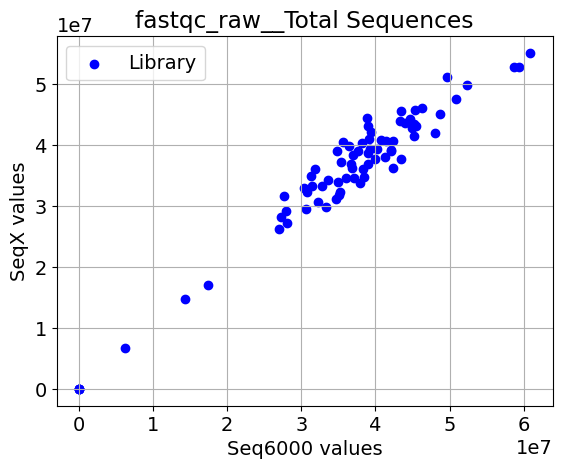

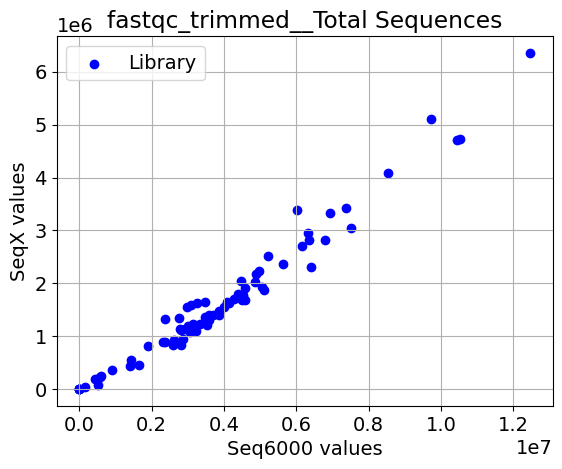

In [168]:
def scatter_plot(full_dataset, protocol, value_column):
    if protocol == "Single":
        filter = full_dataset["Protocol"] == "Single"
    
    elif protocol == "Double":
        filter = full_dataset["Protocol"] == "Double"
    
    elif protocol == "Both":
        filter = (full_dataset["Protocol"] == "Single") | (full_dataset["Protocol"] == "Double")
        
    else:
        raise Exception()
    
    full_dataset = full_dataset[filter]
    data_nsX = full_dataset[(full_dataset["Platform"] == "NovaSeqX") & (full_dataset["Read Type"] == "R1") & (full_dataset["Lane"] == "L005")]
    data_ns6 = full_dataset[(full_dataset["Platform"] == "NovaSeq6") & (full_dataset["Read Type"] == "R1") & (full_dataset["Lane"] == "L004")]
    
    x = data_nsX[["library_id", value_column]].groupby("library_id").sum().reset_index().sort_values("library_id")[value_column]
    y = data_ns6[["library_id", value_column]].groupby("library_id").sum().reset_index().sort_values("library_id")[value_column]

    # Create scatter plot
    plt.scatter(y, x, color='blue', label='Library', marker='o')
    
    # Customize the plot
    plt.title(value_column)  # Add a title
    plt.xlabel("Seq6000 values")  # Label for x-axis
    plt.ylabel("SeqX values")  # Label for y-axis
    plt.legend()  # Show legend
    plt.grid(True)  # Add gridlines
    plt.show()  # Display the plot
scatter_plot(all_multiqc_data, "Double", "fastqc_raw__Total Sequences")
scatter_plot(all_multiqc_data, "Double", "fastqc_trimmed__Total Sequences")

Total reads sequenced plot

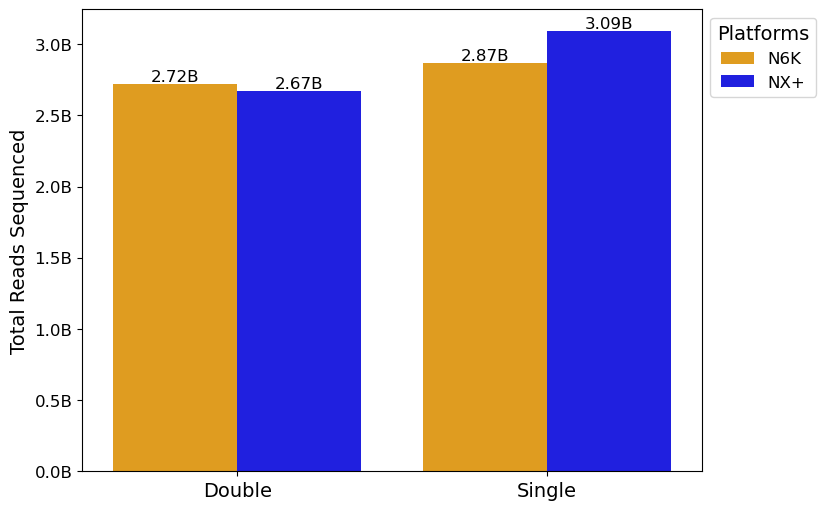

In [167]:
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import matplotlib.pyplot as plt

font_size = 12

tmp = pd.concat([all_multiqc_data[(all_multiqc_data['Platform'] == 'NovaSeqX') 
                  & (all_multiqc_data['Lane'] == 'L005')],
 all_multiqc_data[(all_multiqc_data['Platform'] == 'NovaSeq6') 
                  & (all_multiqc_data['Lane'] == 'L004')]])

# Create the bar plot
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=tmp[(tmp["Read Type"] == "R1")][['Platform', 'Protocol', "fastqc_raw__Total Sequences"]].groupby(["Platform", 'Protocol']).sum(),
    x="Protocol",
    y="fastqc_raw__Total Sequences",
    hue="Platform",  # Group bars by platform
    palette=["orange", "blue"],  # Custom colors
)

# Format y-axis in billions
def billions(x, pos):
    return f'{x / 1e9:.1f}B'  # Format y-axis values in billions

for container in ax.containers:
    ax.bar_label(
        container, 
        labels=[f"{v.get_height()/1000000000:.2f}B" for v in container],  # Format as billions with 1 decimal place
        label_type="edge", 
        fontsize=font_size
    )
ax.yaxis.set_major_formatter(FuncFormatter(billions))

# Add labels and title
plt.xlabel("", fontsize=font_size)
plt.ylabel("Total Reads Sequenced", fontsize=font_size+2)
plt.xticks(fontsize=font_size+2)
plt.yticks(fontsize=font_size)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=font_size)  # Adjust as needed

# Change the legend labels
new_labels = ['N6K', 'NX+']  # Customize as needed
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, new_labels, title="Platforms", loc='upper left', bbox_to_anchor=(1, 1), fontsize=font_size)

plt.show()


Compare raw output between lanes on NovaSeq6:

<Axes: title={'center': 'NovaSeq6 Double'}, xlabel='Lane'>

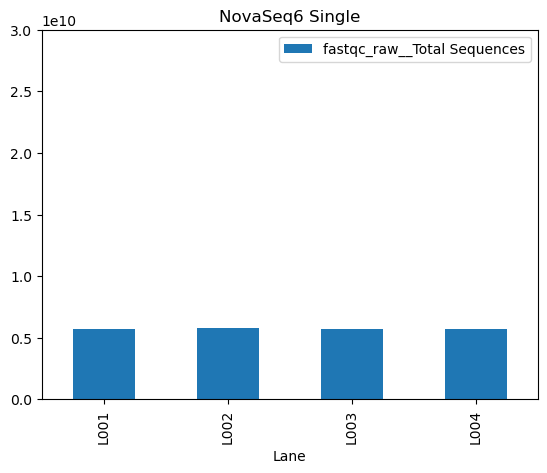

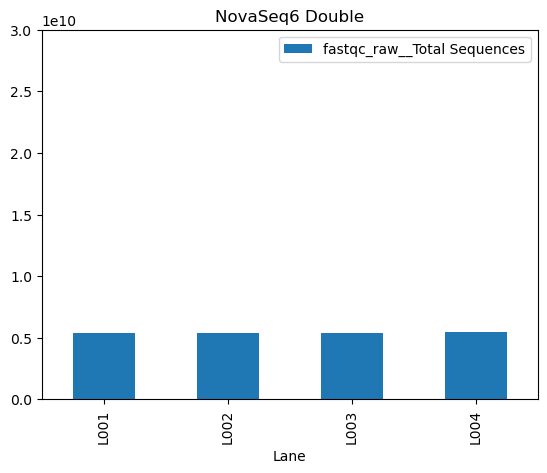

In [20]:
group = data_ns6[data_ns6["Protocol"] == "Single"][["Lane", "fastqc_raw__Total Sequences"]].groupby(["Lane"]).sum()
group_reset = group[group["fastqc_raw__Total Sequences"] > 0].reset_index()
group_reset.plot(kind="bar", x="Lane", title="NovaSeq6 Single", ylim=(0, 3e10))

group = data_ns6[data_ns6["Protocol"] == "Double"][["Lane", "fastqc_raw__Total Sequences"]].groupby(["Lane"]).sum()
group_reset = group[group["fastqc_raw__Total Sequences"] > 0].reset_index()
group_reset.plot(kind="bar", x="Lane", title="NovaSeq6 Double", ylim=(0, 3e10))

Verify that all libraries have been sequenced on all lanes:

In [169]:
for id in all_multiqc_data["library_id"].unique():
    if len(all_multiqc_data[(all_multiqc_data["Platform"] == "NovaSeq6") & (~all_multiqc_data["fastqc_raw__Total Sequences"].isna()) & (all_multiqc_data["library_id"] == id)]["Lane"].unique()) != 4:
        print("Error")
        
for id in all_multiqc_data["library_id"].unique():
    if len(all_multiqc_data[(all_multiqc_data["Platform"] == "NovaSeqX") & (~all_multiqc_data["fastqc_raw__Total Sequences"].isna()) & (all_multiqc_data["library_id"] == id)]["Lane"].unique()) != 4:
        print("Error")

Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error


Output from fastp single stranded

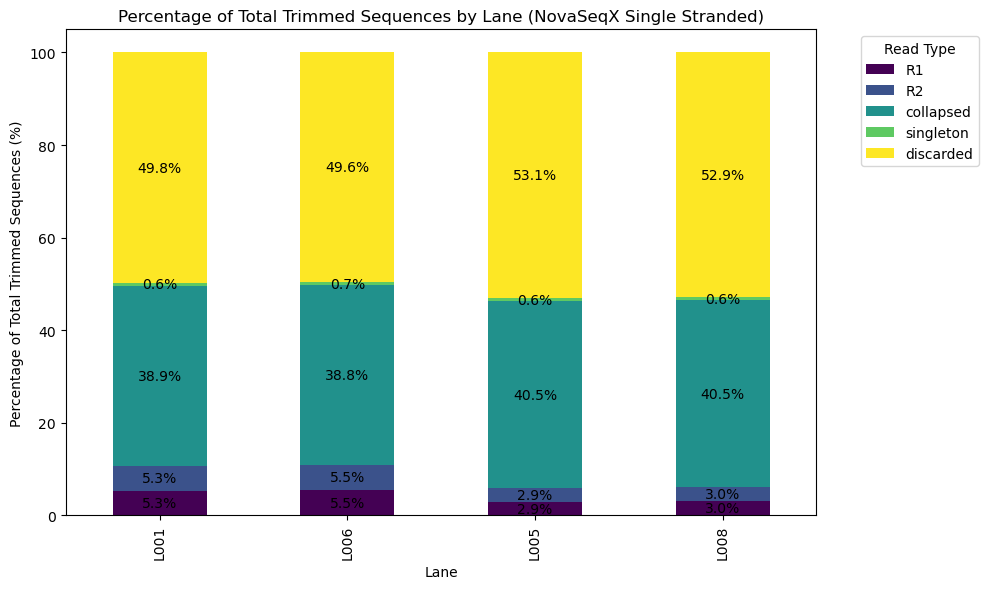

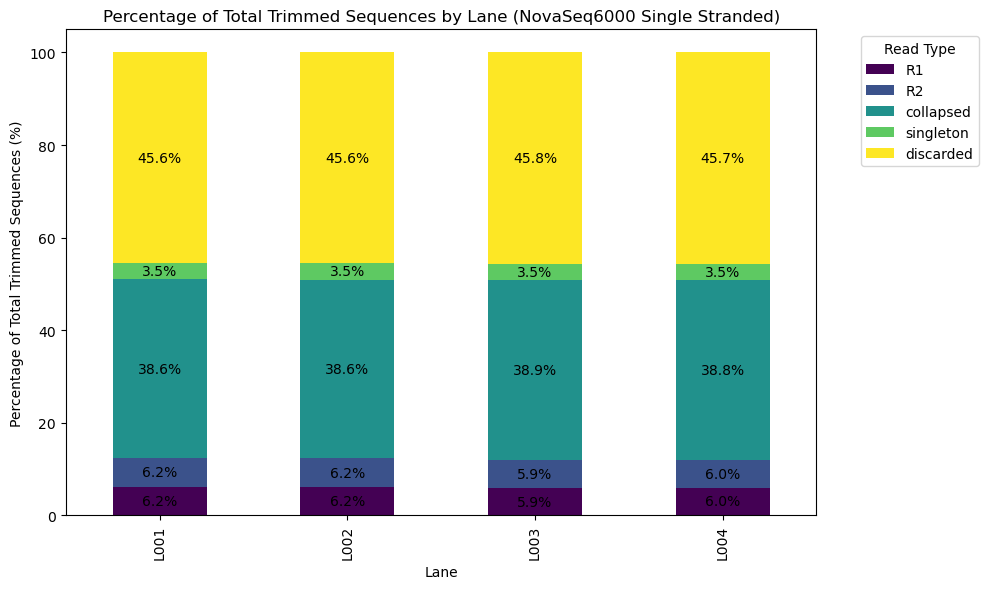

In [21]:
group = data_nsX[data_nsX["Protocol"] == "Single"][["Lane", "Read Type" , "fastqc_trimmed__Total Sequences", 'fastqc_raw__Total Sequences']].groupby(["Lane", "Read Type"]).sum()
group_reset = group[group["fastqc_trimmed__Total Sequences"] > 0].reset_index()

# Calculate the total sequences per Lane for normalization
group_reset["Total_Per_Lane"] = group_reset.groupby("Lane")['fastqc_raw__Total Sequences'].transform("sum")

# Calculate the percentage for each Read Type
group_reset["Percentage"] = (group_reset["fastqc_trimmed__Total Sequences"] / group_reset["Total_Per_Lane"]) * 100

# Pivot to prepare the data for the plot (use percentages)
pivot_data_percentage = group_reset.pivot(index="Lane", columns="Read Type", values="Percentage")

pivot_data_percentage= pivot_data_percentage.loc[["L001", "L006", "L005", "L008"]]

pivot_data_percentage['discarded'] = 100 - (pivot_data_percentage['R1'] + pivot_data_percentage['R2'] + pivot_data_percentage['collapsed'] + pivot_data_percentage['singleton'])

# Plot the stacked bar chart with percentages
ax = pivot_data_percentage.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")

# Annotate the percentages on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')  # Display percentages with one decimal place

# Add labels and title
plt.title("Percentage of Total Trimmed Sequences by Lane (NovaSeqX Single Stranded)")
plt.xlabel("Lane")
plt.ylabel("Percentage of Total Trimmed Sequences (%)")
plt.legend(title="Read Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

group = data_ns6[data_ns6["Protocol"] == "Single"][["Lane", "Read Type" , "fastqc_trimmed__Total Sequences", 'fastqc_raw__Total Sequences']].groupby(["Lane", "Read Type"]).sum()
group_reset = group[group["fastqc_trimmed__Total Sequences"] > 0].reset_index()

# Calculate the total sequences per Lane for normalization
group_reset["Total_Per_Lane"] = group_reset.groupby("Lane")["fastqc_raw__Total Sequences"].transform("sum")

# Calculate the percentage for each Read Type
group_reset["Percentage"] = (group_reset["fastqc_trimmed__Total Sequences"] / group_reset["Total_Per_Lane"]) * 100

# Pivot to prepare the data for the plot (use percentages)
pivot_data_percentage = group_reset.pivot(index="Lane", columns="Read Type", values="Percentage")

pivot_data_percentage= pivot_data_percentage.loc[["L001", "L002", "L003", "L004"]]

pivot_data_percentage['discarded'] = 100 - (pivot_data_percentage['R1'] + pivot_data_percentage['R2'] + pivot_data_percentage['collapsed'] + pivot_data_percentage['singleton'])


# Plot the stacked bar chart with percentages
ax = pivot_data_percentage.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")

# Annotate the percentages on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')  # Display percentages with one decimal place

# Add labels and title
plt.title("Percentage of Total Trimmed Sequences by Lane (NovaSeq6000 Single Stranded)")
plt.xlabel("Lane")
plt.ylabel("Percentage of Total Trimmed Sequences (%)")
plt.legend(title="Read Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Output from fastp ds + ss

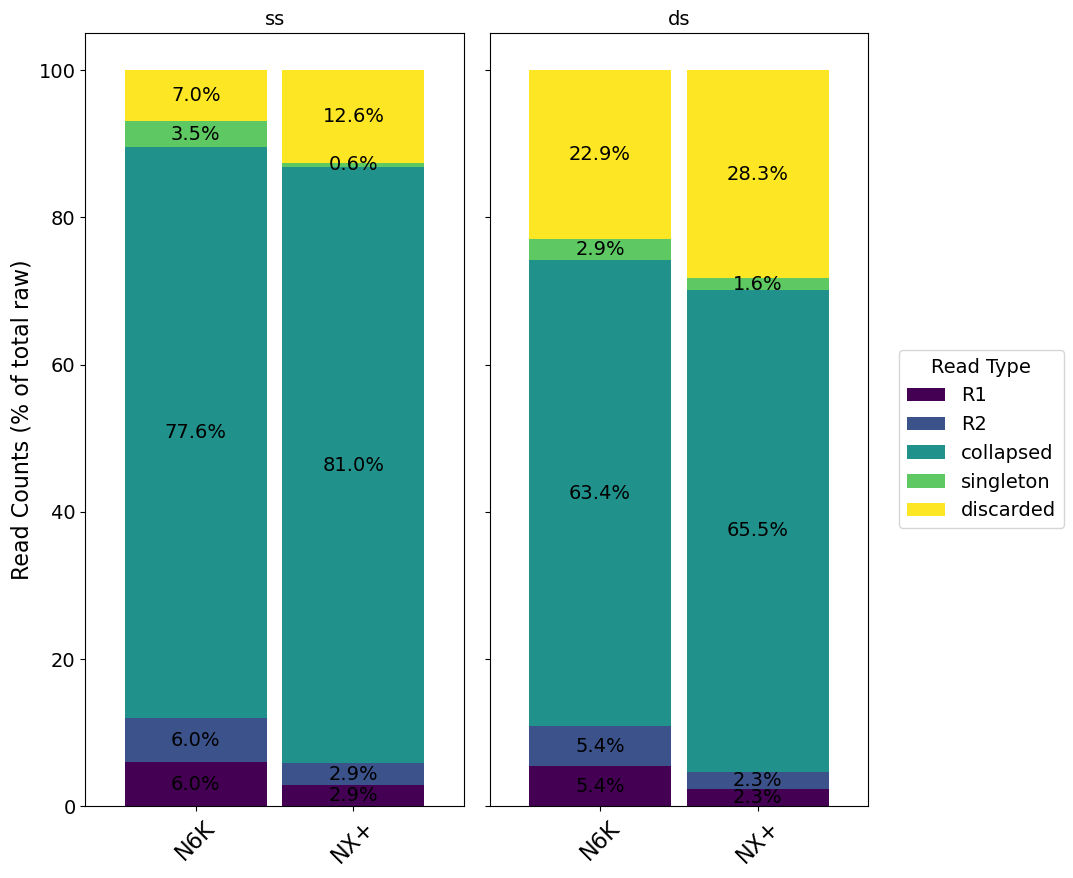

In [165]:
import pandas as pd
import matplotlib.pyplot as plt
font_size = 14
# Set global font size for all text elements
plt.rcParams.update({'font.size': 14})

# Data for Single Stranded Flow Cell (NSX)
tmp = pd.concat([all_multiqc_data[(all_multiqc_data['Platform'] == 'NovaSeqX') 
                                  & (all_multiqc_data['Lane'] == 'L005')],
                 all_multiqc_data[(all_multiqc_data['Platform'] == 'NovaSeq6') 
                                  & (all_multiqc_data['Lane'] == 'L004')]])

# Process NSX data (Single)
group_nsX_single = tmp[(tmp["Protocol"] == "Single")][["Platform", 
                                                     "Read Type", 
                                                     "fastqc_trimmed__Total Sequences", 
                                                     "fastqc_raw__Total Sequences"]].groupby(["Platform", "Read Type"]).sum()

group_reset_nsX_single = group_nsX_single[group_nsX_single["fastqc_trimmed__Total Sequences"] > 0].reset_index()
group_reset_nsX_single["Total_Per_Platform"] = group_reset_nsX_single.groupby("Platform")["fastqc_raw__Total Sequences"].transform("sum") 
group_reset_nsX_single["Percentage"] = (group_reset_nsX_single["fastqc_trimmed__Total Sequences"] / group_reset_nsX_single["Total_Per_Platform"]) * 100

pivot_nsX_single = group_reset_nsX_single.pivot(index="Platform", columns="Read Type", values="Percentage")

pivot_nsX_single['collapsed'] = pivot_nsX_single["collapsed"] * 2
pivot_nsX_single["discarded"] = 100 - (pivot_nsX_single["R1"] + pivot_nsX_single["R2"] + pivot_nsX_single["collapsed"] + pivot_nsX_single["singleton"])

# Data for Double Stranded Flow Cell (NSX)
group_nsX_double = tmp[(tmp["Protocol"] == "Double")][["Platform", 
                                                     "Read Type",
                                                     "fastqc_trimmed__Total Sequences",
                                                     "fastqc_raw__Total Sequences"]].groupby(["Platform", "Read Type"]).sum()

group_reset_nsX_double = group_nsX_double[group_nsX_double["fastqc_trimmed__Total Sequences"] > 0].reset_index()

group_reset_nsX_double["Total_Per_Lane"] = group_reset_nsX_double.groupby("Platform")["fastqc_raw__Total Sequences"].transform("sum")
group_reset_nsX_double["Percentage"] = (group_reset_nsX_double["fastqc_trimmed__Total Sequences"] / group_reset_nsX_double["Total_Per_Lane"]) * 100

pivot_nsX_double = group_reset_nsX_double.pivot(index="Platform", columns="Read Type", values="Percentage")

pivot_nsX_double['collapsed'] = pivot_nsX_double["collapsed"] * 2
pivot_nsX_double["discarded"] = 100 - (pivot_nsX_double["R1"] + pivot_nsX_double["R2"] + pivot_nsX_double["collapsed"] + pivot_nsX_double["singleton"])

# Create a figure with 2 subplots (side by side)
fig, axes = plt.subplots(1, 2, figsize=(10, 9), sharey=True)  # Adjusted width for a more compact layout

# Plot for Single Stranded Flow Cell
pivot_nsX_single.index.name = "Platform"
ax1 = pivot_nsX_single.plot(kind="bar", stacked=True, ax=axes[0], colormap="viridis", width=0.9, legend=False)
for container in ax1.containers:
    ax1.bar_label(container, fmt="%.1f%%", label_type="center")
ax1.set_title("ss", fontsize=font_size)
ax1.set_ylabel("Read Counts (% of total raw)", fontsize=font_size+2)
ax1.set_xlabel('', fontsize=font_size+2)
ax1.set_xticklabels(['N6K', 'NX+'], rotation=45, fontsize=font_size+2)

# Plot for Double Stranded Flow Cell
pivot_nsX_double.index.name = "Platform"
ax2 = pivot_nsX_double.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis", width=0.9, legend=False)
for container in ax2.containers:
    ax2.bar_label(container, fmt="%.1f%%", label_type="center")
ax2.set_title("ds", fontsize=font_size)
ax2.set_xlabel('', fontsize=font_size)
ax2.set_ylabel("Read Counts (% of total raw)", fontsize=font_size+2)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, fontsize=font_size+2)
ax2.set_xticklabels(['N6K', 'NX+'], rotation=45, fontsize=font_size+2)


# Manually create the legend from the handles of the first plot
handles, labels = ax1.get_legend_handles_labels()

# Add a single legend to the right of the plots
fig.legend(handles, labels, title="Read Type", bbox_to_anchor=(0.9, 0.5), loc="center left", fontsize=font_size)

# Adjust layout for better spacing and more compact look
plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust layout to leave space for the legend
plt.show()


Median sequence length collapsed boxplot

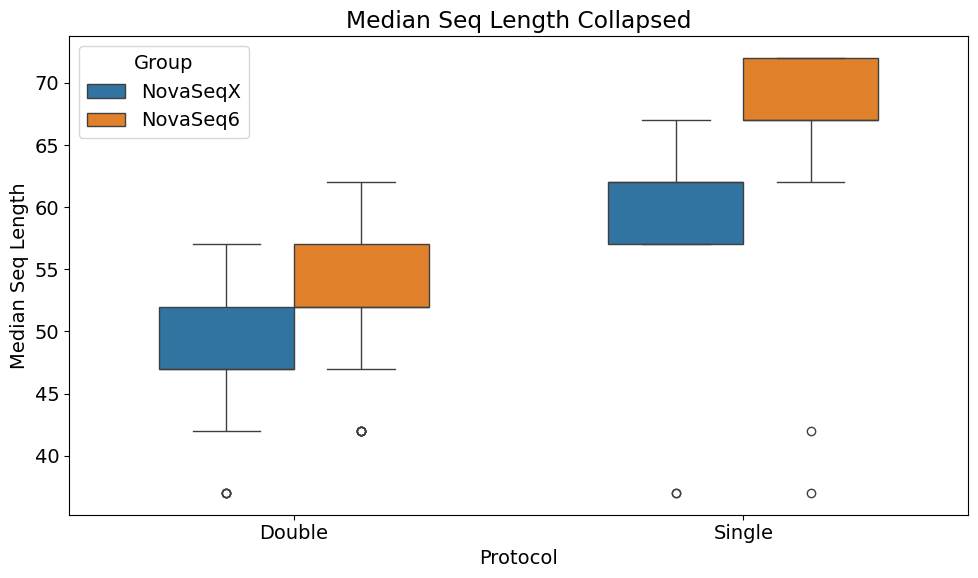

In [172]:
read_type = "collapsed"
stat = 'fastqc_trimmed__median_sequence_length'

tmp = pd.concat([all_multiqc_data[(all_multiqc_data['Platform'] == 'NovaSeqX') 
                  & (all_multiqc_data['Lane'] == 'L005')],
 all_multiqc_data[(all_multiqc_data['Platform'] == 'NovaSeq6') 
                  & (all_multiqc_data['Lane'] == 'L004')]])

# Example DataFrame
data = tmp[(tmp['Read Type'] == read_type)]

# Create a grouped boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Protocol", y=stat, hue='Platform', data=data, width=0.6)

# Add title and labels
plt.title("Median Seq Length Collapsed")
plt.xlabel("Protocol")
plt.ylabel("Median Seq Length")

plt.legend(title="Group")
plt.tight_layout()
plt.show()


Median sequence length double stranded singleton per library

In [178]:
# Filter the data for the specific conditions
filtered_data = data_nsX_ds[
    (data_nsX_ds['Lane'] == 'L005') & (data_nsX_ds['Read Type'] == 'singleton')
]

# Create the bar plot
fig = px.bar(
    data_frame=filtered_data,
    x="library_id",
    y="fastqc_trimmed__median_sequence_length",
    title="Median Sequence Length by Library ID (L005 - singleton, double)",
    labels={
        "library_id": "Library ID",
        "fastqc_trimmed__median_sequence_length": "Median Sequence Length"
    }
)

# Rotate x-axis labels
fig.update_layout(
    xaxis_tickangle=90,  # Rotate x-axis labels 90 degrees
    height=600,         # Adjust the height of the plot
    width=1000          # Adjust the width of the plot
)

# Show the plot
fig.show()


GC Content boxplots

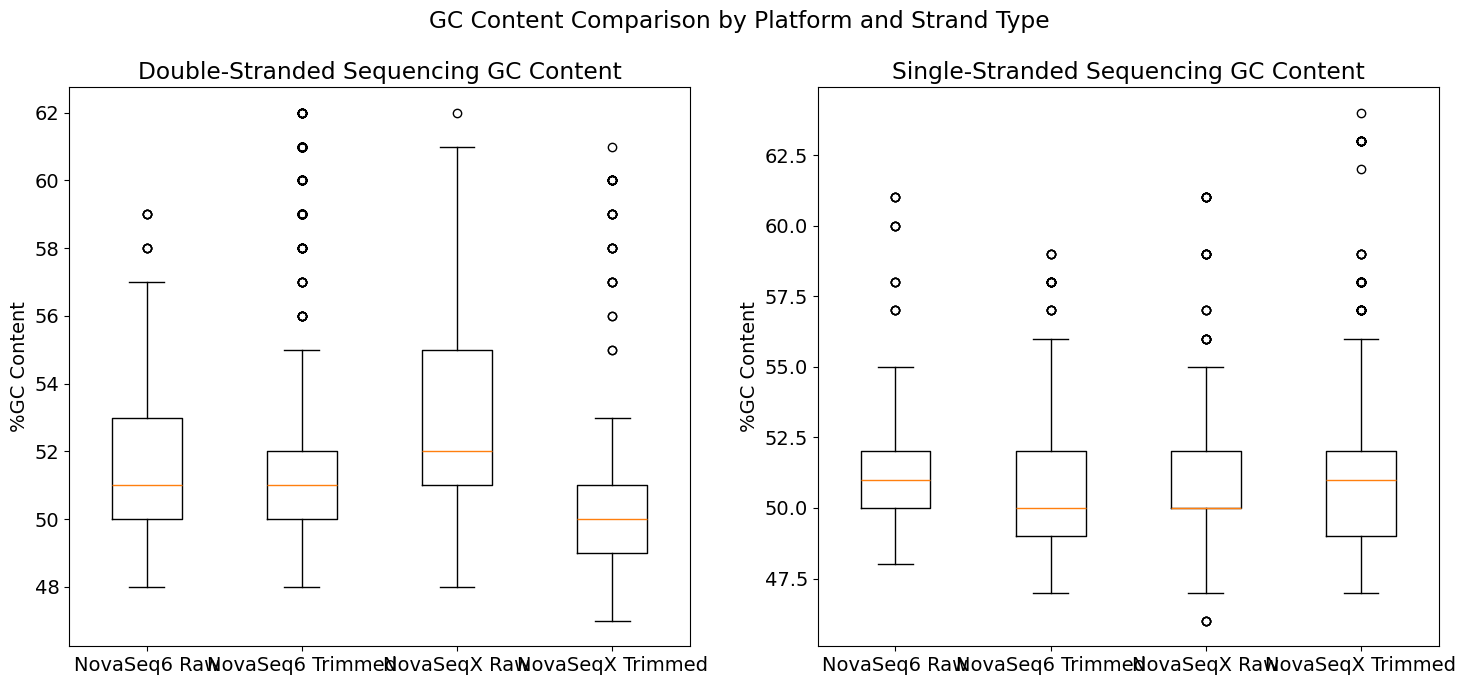

In [184]:
def make_boxplots(data, data_types, platforms, title, ax):
    gc_data = []
    labels = []

    for platform in platforms:
        for data_type in data_types:
            gc_content = data[data['Platform'] == platform][data_type].dropna()
            gc_data.append(gc_content)
            labels.append(f'{platform} {"Raw" if "raw" in data_type else "Trimmed"}')
    
    ax.boxplot(gc_data, tick_labels=labels)
    ax.set_title(title)
    ax.set_ylabel('%GC Content')

# Set up the plot
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

# Platforms
platforms = all_multiqc_data["Platform"].unique()

describe_cols = [r"fastqc_raw__%GC", r"fastqc_trimmed__%GC"]

# Plot GC content for double-stranded and single-stranded sequencing
make_boxplots(all_multiqc_data[all_multiqc_data["Protocol"] == "Double"], describe_cols, platforms, 'Double-Stranded Sequencing GC Content', axs[0])
make_boxplots(all_multiqc_data[all_multiqc_data["Protocol"] == "Single"], describe_cols, platforms, 'Single-Stranded Sequencing GC Content', axs[1])

# Display the plot
plt.suptitle('GC Content Comparison by Platform and Strand Type')
plt.tight_layout()
plt.show()

Double stranded fail/pass MultiQC exploration

In [183]:
cols = ['fastqc_raw__per_tile_sequence_quality', 
        'fastqc_raw__sequence_length_distribution', 
        'fastqc_trimmed__per_base_sequence_content',
        'fastqc_trimmed__per_tile_sequence_quality']


for col in cols:
    print("ds")
    print('ns6')
    print(data_ns6_ds.query('Lane == "L004"')[col].value_counts())
    print('nsX')
    print(data_nsX_ds.query('Lane == "L005"')[col].value_counts())
    print("ss")
    print('ns6')
    print(data_ns6_ss.query('Lane == "L004"')[col].value_counts())
    print('nsX')
    print(data_nsX_ss.query('Lane == "L005"')[col].value_counts())

ds
ns6
fastqc_raw__per_tile_sequence_quality
pass    142
fail      8
Name: count, dtype: int64
nsX
fastqc_raw__per_tile_sequence_quality
fail    150
Name: count, dtype: int64
ss
ns6
fastqc_raw__per_tile_sequence_quality
pass    91
warn     1
Name: count, dtype: int64
nsX
fastqc_raw__per_tile_sequence_quality
fail    92
Name: count, dtype: int64
ds
ns6
fastqc_raw__sequence_length_distribution
pass    150
Name: count, dtype: int64
nsX
fastqc_raw__sequence_length_distribution
pass    150
Name: count, dtype: int64
ss
ns6
fastqc_raw__sequence_length_distribution
pass    92
Name: count, dtype: int64
nsX
fastqc_raw__sequence_length_distribution
warn    92
Name: count, dtype: int64
ds
ns6
fastqc_trimmed__per_base_sequence_content
pass    207
warn     52
fail     41
Name: count, dtype: int64
nsX
fastqc_trimmed__per_base_sequence_content
pass    247
warn     42
fail     11
Name: count, dtype: int64
ss
ns6
fastqc_trimmed__per_base_sequence_content
warn    77
fail    64
pass    43
Name: count, dty